<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project-6/Images-Description.for.Students_Pass_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning



This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.



The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.



There are three files in this data set:
- [the feature set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle ), i.e. images of dogs and cats ( mostly )
- [the target set]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle ), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image]( https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg )





This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.


The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.




https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg


In [1]:
import pandas as pd


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape

(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

In [7]:
image_url = ''

## Library Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
import urllib.request
import cv2

In [9]:
# Verify GPU is enabled and detected by TensorFlow
print("GPU Devices Available: ", tf.config.list_physical_devices('GPU'))

# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url))

# Subsample for Pass 4 (5,000 images, randomized)

np.random.seed(42)
indices = np.arange(len(X_full))
np.random.shuffle(indices)

# INCREASE TO 5000

subset_indices = indices[:5000]
X_subset = X_full[subset_indices]
y_subset = y_full[subset_indices]

# Data Cleaning (Scaling)

X_subset = X_subset / 255.0

GPU Devices Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Collection

### Load Pickled Data

In [ ]:
# Load the Pickled Data

X_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
y_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"

X_full = pd.read_pickle(X_url)
y_full = np.array(pd.read_pickle(y_url))

# Subsample for Pass 3 (2,000 images, randomized)

np.random.seed(42) # Keeping the same seed maintains continuity
indices = np.arange(len(X_full))
np.random.shuffle(indices)

# INCREASE TO 2000

subset_indices = indices[:2000]
X_subset = X_full[subset_indices]
y_subset = y_full[subset_indices]

# Data Cleaning (Scaling)
# Scale the values so that they fall between 0 and 1

X_subset = X_subset / 255.0

### Exploratory Data Analysis (EDA)

In [10]:
# Verify Dimensionality

print(f"X_subset shape: {X_subset.shape}") # Should be (5000, 100, 100, 1)
print(f"y_subset shape: {y_subset.shape}") # Should be (5000,)

X_subset shape: (5000, 100, 100, 1)
y_subset shape: (5000,)


### Visual Inspection and Label Verification

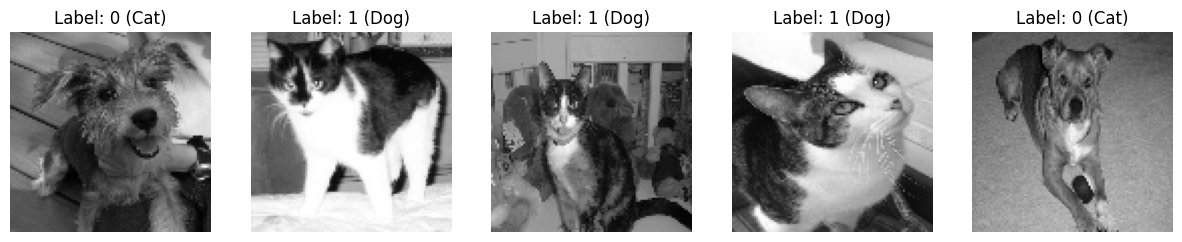

In [11]:
# Visual Inspection and Label Verification

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_subset[i].reshape(100, 100), cmap='gray')
    label = "Dog" if y_subset[i] == 1 else "Cat"
    plt.title(f"Label: {y_subset[i]} ({label})")
    plt.axis('off')
plt.show()

## CNN Architecture & Compilation

### Train_Test Split

In [ ]:
# Train-Test Split (80/20 split)

# This will result in 1,600 training images and 400 testing images

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

# Build the Sequential Model
model = Sequential()

# Add Convolutional Blocks

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train-Test Split (80/20 split)

# This results in 4,000 training images and 1,000 testing images

X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.20, random_state=42
)

# Build the Sequential Model

model = Sequential()

# Add Convolutional Blocks

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Define the Output Layer

model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

# Compile the Engine

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Prediction

### Fitting The Model

In [15]:
# Fit the Model

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

# Evaluate Performance

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# External Prediction Function

def predict_external_image(image_url, current_model):
    req = urllib.request.urlopen(image_url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, (100, 100))
    img_scaled = img_resized / 255.0
    img_reshaped = img_scaled.reshape(1, 100, 100, 1)

    prediction = current_model.predict(img_reshaped)[0][0]
    predicted_class = "Dog" if prediction > 0.5 else "Cat"

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class} (Prob: {prediction:.4f})")
    plt.axis('off')
    plt.show()

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8940 - loss: 0.2599 - val_accuracy: 0.7030 - val_loss: 0.7183
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9062 - loss: 0.2363 - val_accuracy: 0.7060 - val_loss: 0.7132
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9345 - loss: 0.1916 - val_accuracy: 0.7030 - val_loss: 0.7756
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9425 - loss: 0.1629 - val_accuracy: 0.7150 - val_loss: 0.8314
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9630 - loss: 0.1280 - val_accuracy: 0.7020 - val_loss: 0.8985
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9730 - loss: 0.1060 - val_accuracy: 0.7150 - val_loss: 0.9921
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9755 - loss: 0.0914 - val_accuracy: 0.6980 - val_loss: 1.0305
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9852 - loss: 0.0704 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


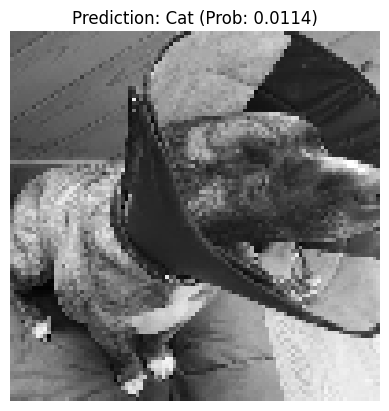

In [14]:
# Test the function with the provided dog image

dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
predict_external_image(dog_url, model)

## Pass 2 Analytical Review

In [16]:
# Generate predictions for the test set

test_predictions = model.predict(X_test).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


NOTE FOR ANALYSIS:
With 2,000 images, the U-shape should be highly pronounced. The model is committing more decisively to its predictions, meaning fewer probabilities will land in the ambiguous 0.4 to 0.6 range.

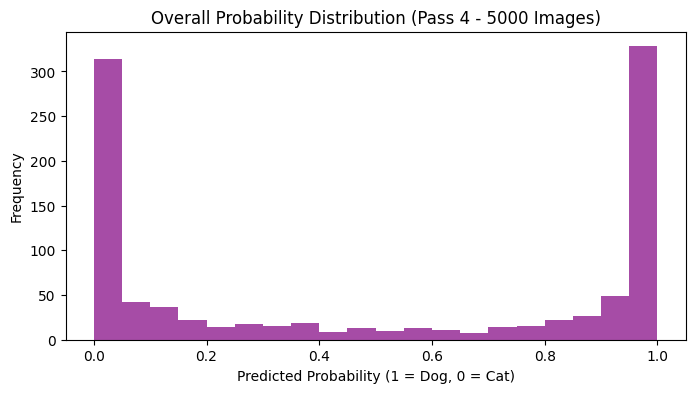

In [17]:
# How do the distributions of probabilities change as the number of images increase?

plt.figure(figsize=(8, 4))
plt.hist(test_predictions, bins=20, color='purple', alpha=0.7)
plt.title("Overall Probability Distribution (Pass 4 - 5000 Images)")
plt.xlabel("Predicted Probability (1 = Dog, 0 = Cat)")
plt.ylabel("Frequency")
plt.show()

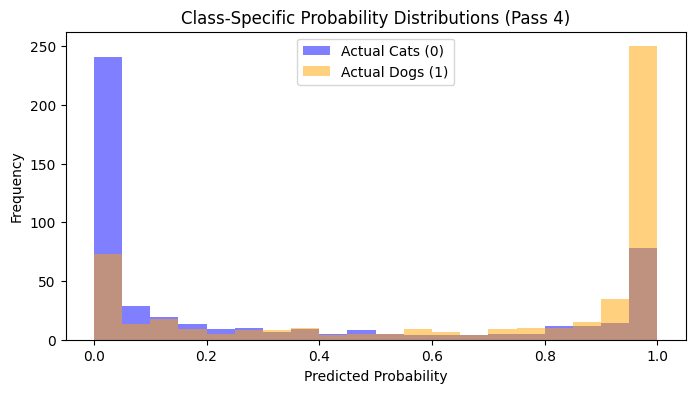

In [18]:
# How do the distributions of probabilities for each class change?

plt.figure(figsize=(8, 4))
plt.hist(test_predictions[y_test == 0], bins=20, color='blue', alpha=0.5, label='Actual Cats (0)')
plt.hist(test_predictions[y_test == 1], bins=20, color='orange', alpha=0.5, label='Actual Dogs (1)')
plt.title("Class-Specific Probability Distributions (Pass 4)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [19]:
# NOTE FOR ANALYSIS: The separation between the two classes should be cleaner now, with the blue bars clustering near 0 and the orange bars clustering near 1.

# High-Confidence False Positives (Actually Dog, Predicted Cat)

false_cats = np.where((y_test == 1) & (test_predictions < 0.1))[0]

# High-Confidence False Negatives (Actually Cat, Predicted Dog)

false_dogs = np.where((y_test == 0) & (test_predictions > 0.9))[0]

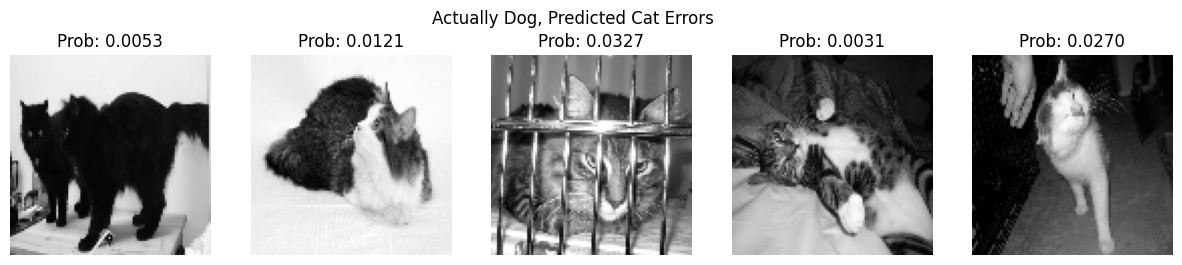

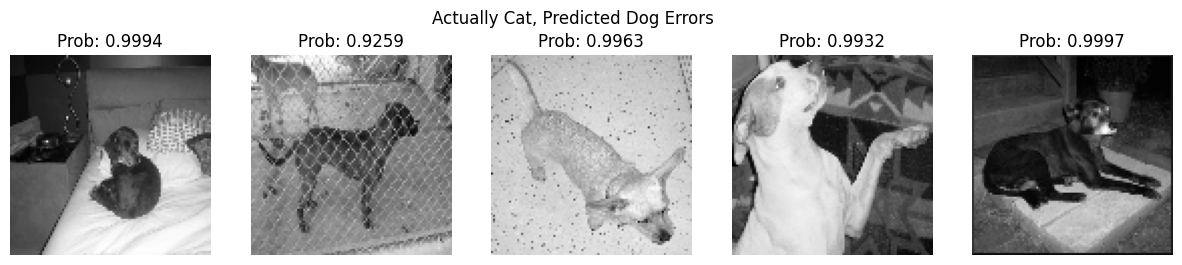

In [20]:
# Did you find any odd images? Visually inspect the high-confidence errors.

def plot_errors(error_indices, title_prefix):
    if len(error_indices) == 0:
        print(f"No {title_prefix} found at this confidence threshold.")
        return

    plt.figure(figsize=(15, 3))
    # Plot up to 5 errors
    plot_count = min(len(error_indices), 5)
    for i in range(plot_count):
        idx = error_indices[i]
        plt.subplot(1, 5, i+1)
        plt.imshow(X_test[idx].reshape(100, 100), cmap='gray')
        plt.title(f"Prob: {test_predictions[idx]:.4f}")
        plt.axis('off')
    plt.suptitle(f"{title_prefix} Errors")
    plt.show()

plot_errors(false_cats, "Actually Dog, Predicted Cat")
plot_errors(false_dogs, "Actually Cat, Predicted Dog")

## Hyperparameter Experimentation

In [21]:
from tensorflow.keras.layers import Dropout

In [22]:
# Experimental Model: Changing the activation function to 'tanh'
exp_model_4 = Sequential()

# Block 1
exp_model_4.add(Conv2D(32, kernel_size=(3, 3), activation='tanh', input_shape=(100, 100, 1)))
exp_model_4.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
exp_model_4.add(Conv2D(64, kernel_size=(3, 3), activation='tanh'))
exp_model_4.add(MaxPooling2D(pool_size=(2, 2)))

# Output Layer
exp_model_4.add(Flatten())
exp_model_4.add(Dense(1, activation='sigmoid'))

exp_model_4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model
exp_history_4 = exp_model_4.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5940 - loss: 0.6648 - val_accuracy: 0.6240 - val_loss: 0.6473
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6755 - loss: 0.6013 - val_accuracy: 0.7020 - val_loss: 0.5916
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7435 - loss: 0.5200 - val_accuracy: 0.7150 - val_loss: 0.5629
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7922 - loss: 0.4554 - val_accuracy: 0.6930 - val_loss: 0.6071
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8198 - loss: 0.4019 - val_accuracy: 0.7320 - val_loss: 0.5840
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8583 - loss: 0.3376 - val_accuracy: 0.7300 - val_loss: 0.5964
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8900 - loss: 0.2866 - val_accuracy: 0.7270 - val_loss: 0.6326
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9118 - loss: 0.2386 - val_accu

In [ ]:
# Experimental Model: Adding an intermediate Dense layer and Dropout to combat overfitting

exp_model_3 = Sequential()

# Block 1

exp_model_3.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
exp_model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2

exp_model_3.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
exp_model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Flattening

exp_model_3.add(Flatten())

# New Intermediate Dense Layer with Dropout

exp_model_3.add(Dense(64, activation='relu'))
exp_model_3.add(Dropout(0.5)) # Randomly drops 50% of connections during training

# Output Layer

exp_model_3.add(Dense(1, activation='sigmoid'))

exp_model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the experimental model

exp_history_3 = exp_model_3.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 458ms/step - accuracy: 0.5231 - loss: 0.6938 - val_accuracy: 0.5525 - val_loss: 0.6902
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 413ms/step - accuracy: 0.5775 - loss: 0.6852 - val_accuracy: 0.5850 - val_loss: 0.6802
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 421ms/step - accuracy: 0.6288 - loss: 0.6525 - val_accuracy: 0.5700 - val_loss: 0.6804
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 425ms/step - accuracy: 0.6687 - loss: 0.6110 - val_accuracy: 0.6200 - val_loss: 0.6379
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 428ms/step - accuracy: 0.7275 - loss: 0.5565 - val_accuracy: 0.6525 - val_loss: 0.6361
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 403ms/step - accuracy: 0.7700 - loss: 0.4859 - val_accuracy: 0.6700 - val_loss: 0.6260
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 417ms/step - accuracy: 0.8213 - loss: 0.4248 - val_accuracy: 0.6925 - val_loss: 0.6312
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.8550 - loss: 0.3377 - val_accu